In [1]:
import numpy as np
import torch
import scanpy as sc
import anndata as ad
import pandas as pd
from utils.preprocess import *
import os
import sys
    
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch
from torchdyn.core import NeuralODE
from tqdm import tqdm

from torchcfm.conditional_flow_matching import *
from torchcfm.models import MLP
from torchcfm.utils import plot_trajectories, torch_wrapper
from simulate.simulate import *
from omegaconf import OmegaConf
from utils.hydra import *
from datasets.process import *
from scripts.run_model import *
from eval.eval import *
import matplotlib.pyplot as plt
%matplotlib inline
%reload_ext autoreload
%autoreload 2

[KeOps] Compiling cuda jit compiler engine ... 
[KeOps] Warning : There were warnings or errors :
/usr/bin/ld: cannot find -lnvrtc
collect2: error: ld returned 1 exit status

OK
[pyKeOps] Compiling nvrtc binder for python ... 
[KeOps] Warning : There were warnings or errors :
/usr/bin/ld: cannot find -lnvrtc
collect2: error: ld returned 1 exit status

OK


In [2]:
############################################################

In [3]:
### SETTINGS ###
config = load_config(overrides=['dataset=zebrafish'])

adata = process_data(pc_dim=config.pc_dim, data=config.dataset)
timepoints = sorted(adata.obs['timepoint'].unique().tolist())
tree = adata.uns['tree']

assert config.num_classes == adata.obs['cell_type'].nunique()
OmegaConf.set_struct(config, False)

config.t0_index = 1

/home/mingxuanzhang/anaconda3/lib/python3.12/site-packages/scanpy/preprocessing/_pca/__init__.py:384: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca
/home/mingxuanzhang/finfm/utils/lineage.py:103: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['stoi'] = stoi


In [4]:
#CFM
# config.metric = "cfm"
# config.no_learning = False
# config.metric_max_epochs = 2

In [5]:
# #CFM + UOT
# config.metric = "cfm"
# config.no_learning = True

# config.method = "unbalanced"
# config.reg = 0.01
# config.reg_m = 1.0

In [6]:
# #CFM + Finsler
# config.metric = "cfm"

# config.finsler.use = True
# config.finsler.lamb = 2.0
# config.dummy_kl_weight = 0.3

# config.metric_max_epochs = 2

In [7]:
# #MFM-Euc
# config.metric = "mfm"
# config.mfm.use_euclidean_ot = True

# config.mfm.K = 150
# config.mfm.kappa = 1.5
# config.mfm.epsilon = 1e-1

# config.classifier_max_epochs = 2

In [8]:
# #MFM
# config.metric = "mfm"

# config.mfm.K = 150
# config.mfm.kappa = 1.5
# config.mfm.epsilon = 1e-1

# config.classifier_max_epochs = 2

In [7]:
#MFM + Finsler
config.metric = "mfm"

config.mfm.K = 150
config.mfm.kappa = 1.5
config.mfm.epsilon = 1e-1

config.finsler.use = True
config.finsler.lamb = 0.2
config.dummy_kl_weight = 0.3

In [8]:
adata

AnnData object with n_obs × n_vars = 65554 × 4558
    obs: 'cell', 'Size_Factor', 'n.umi', 'perc_mitochondrial_umis', 'timepoint', 'hash_umis', 'top_to_second_best_ratio', 'expt', 'cell_type_sub', 'cell_type_broad', 'tissue', 'germ_layer', 'log.n.umi', 'num_genes_expressed', 'umap3d_1', 'umap3d_2', 'umap3d_3', 'major_group', 'gene_target', 'mean_nn_time', 'subumap3d_1', 'subumap3d_2', 'subumap3d_3', 'embryo', 'temp', 'n_genes', 'cell_type', 'cell_type_one_hot'
    var: 'gene_short_name', 'id', 'chromosome', 'bp1', 'bp2', 'gene_strand', 'num_cells_expressed', 'n_cells', 'highly_variable'
    uns: 'log1p', 'pca', 'std', 'tree', 'stoi', 'itos'
    obsm: 'X_pca'
    varm: 'PCs'

In [11]:
# from utils.lineage import *
# adj = ZEBRAFISH_NEURAL_ADJACENCY
# tree_cell_types = list(adj.keys()) + list(itertools.chain(*adj.values()))
# tree_cell_types = list(set(tree_cell_types))
# print(tree_cell_types)
# print(len(tree_cell_types))
# print(adata.uns['tree'])
# print([adata.uns['stoi'][x] for x in tree_cell_types])
# N = adata.uns['tree'].shape[0]
# for i in range(N):
#     for j in range(N):
#         if adata.uns['tree'][i][j] == 1.0:
#             print(adata.uns['itos'][i] + ", " + adata.uns['itos'][j])

In [12]:
# sc.pp.neighbors(adata)
# sc.tl.umap(adata)

In [13]:
# fig, axs = plt.subplots(5, figsize=(12, 12))
# for i, t in enumerate(timepoints):
#     sc.pl.umap(adata[adata.obs['timepoint'] == t], color='cell_type', ax=axs[i], title=f"time {t}", show=False)
# plt.tight_layout()
# plt.show()

In [9]:
t0, t1 = timepoints[config.t0_index], timepoints[config.t1_index]
adata = adata[(adata.obs['timepoint'] >= t0) & (adata.obs['timepoint'] <= t1)]
adata_train = adata[adata.obs['timepoint'].isin([t0, t1])]
print(t0, t1)


24 72


In [10]:
singleton_dataloader = build_singleton_dataloader(config, adata_train)
paired_dataloader = build_paired_dataloader(config, adata_train)

In [13]:
adata = process_data(100, use_paga=True)

/home/mingxuanzhang/anaconda3/lib/python3.12/site-packages/scanpy/preprocessing/_pca/__init__.py:384: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca
/home/mingxuanzhang/finfm/utils/lineage.py:103: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['itos'] = itos


In [14]:
adata

AnnData object with n_obs × n_vars = 65554 × 4558
    obs: 'cell', 'Size_Factor', 'n.umi', 'perc_mitochondrial_umis', 'timepoint', 'hash_umis', 'top_to_second_best_ratio', 'expt', 'cell_type_sub', 'cell_type_broad', 'tissue', 'germ_layer', 'log.n.umi', 'num_genes_expressed', 'umap3d_1', 'umap3d_2', 'umap3d_3', 'major_group', 'gene_target', 'mean_nn_time', 'subumap3d_1', 'subumap3d_2', 'subumap3d_3', 'embryo', 'temp', 'n_genes', 'cell_type', 'cell_type_one_hot'
    var: 'gene_short_name', 'id', 'chromosome', 'bp1', 'bp2', 'gene_strand', 'num_cells_expressed', 'n_cells', 'highly_variable'
    uns: 'log1p', 'pca', 'std', 'tree', 'neighbors', 'paga', 'cell_type_sizes', 'stoi', 'itos'
    obsm: 'X_pca'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [23]:
sc.tl.umap(adata, init_pos='paga')

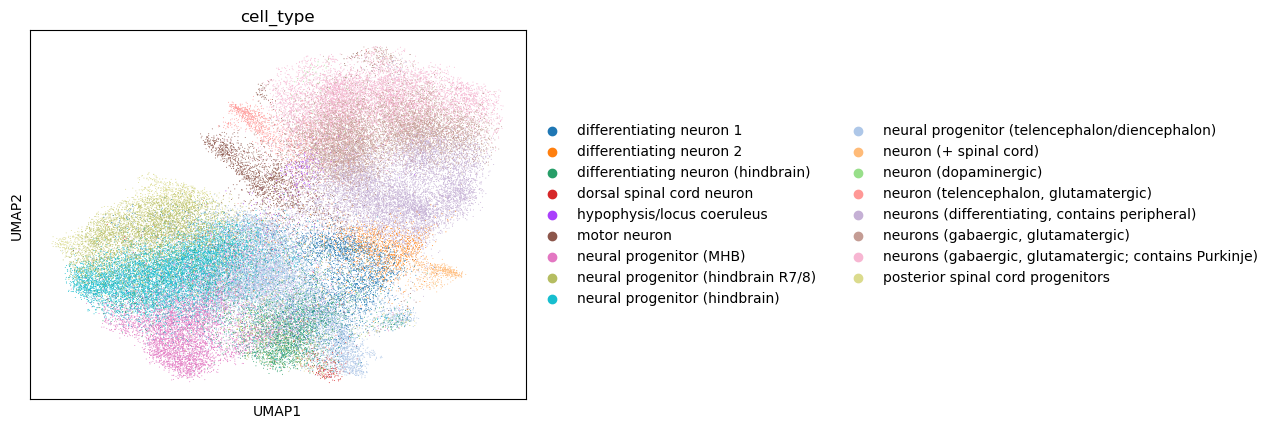

In [31]:
sc.pl.umap(adata, color=['cell_type'])

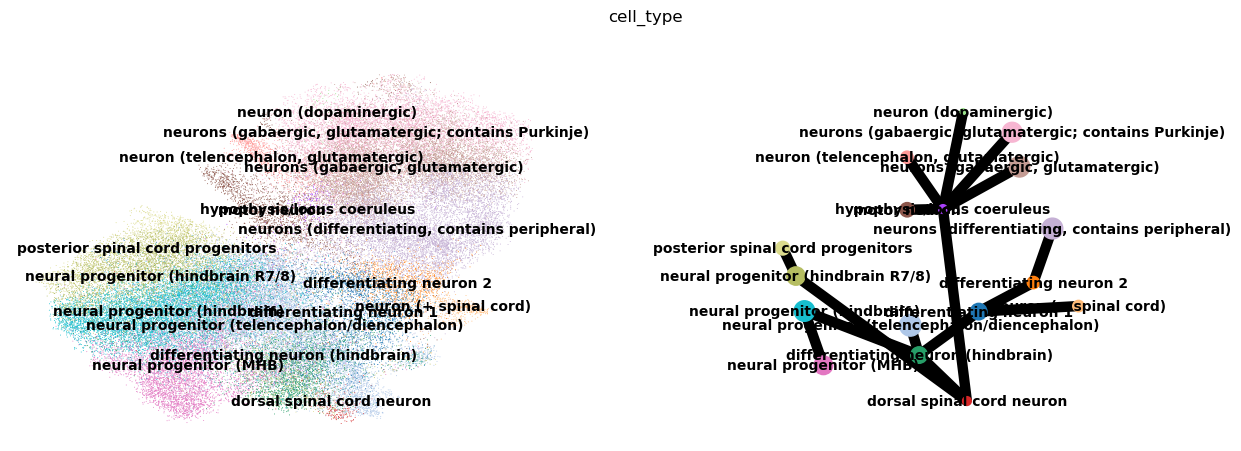

[<Axes: xlabel='UMAP1', ylabel='UMAP2'>, <Axes: >]

In [34]:
sc.pl.paga_compare(
    adata,
    basis="umap",                
    color="cell_type",
    edges=False,                  
    solid_edges="connectivities_tree",  
    dashed_edges=None,           
    threshold=0.0,             
)

In [16]:
classifier_model, metric_model, embed_model, flow_model = run_full_model(config=config,
                                                                         project=config.project,
                                                                         singleton_dataloader=singleton_dataloader,
                                                                         paired_dataloader=paired_dataloader,
                                                                         timepoints=timepoints,
                                                                         tree=tree)

DEBUG: trying dumb first loss as scaling for embed
Running phase classifier:.......


wandb: Currently logged in as: az831 (az831-new-york-genome-center) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
You are using a CUDA device ('NVIDIA GeForce RTX 4080 SUPER') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name           | Type           | Params | Mode 
----------------------------------------------------

epoch,▁▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇███
train_ce,█▃▂▂▂▁▁▂▁▂▁▂▁▂▁▁▂▁▂▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_kl,▁▂▅▅▅▇▇▇████████████████████████████████
train_loss_classifier,█▆▅▄▃▃▃▄▁▃▃▂▄▃▃▃▂▃▃▃▂▂▁▂▂▂▂▁▂▂▃▂▃▂▃▂▃▂▂▁
trainer/global_step,▁▁▂▂▂▂▂▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇███
epoch,999
train_ce,0.54196
train_kl,2.93341
train_loss_classifier,0.68863
trainer/global_step,6999


Running phase metric:.......


...

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type           | Params | Mode 
--------------------------------------------------------
0 | embed_net    | SimpleEmbedNet | 184 K  | train
1 | geo_net      | SinNet         | 226 K  | train
2 | metric_model | MetricNetCFM   | 0      | eval 
--------------------------------------------------------
411 K     Trainable params
0         Non-trainable params
411 K     Total params
1.645     Total estimated model params size (MB)
26        Modules in train 

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▄▄▄▄▄▄▄▄▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇█
train_loss_embed,███▆▆▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
train_loss_geo,█▃▃▂▃▂▂▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▂▂▁▂▂▁▂▂▂▁▂▁▂
trainer/global_step,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇█████
epoch,2999
train_loss_embed,0.01089
train_loss_geo,0.11655
trainer/global_step,2999


Running phase flow:.......


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type              | Params | Mode 
----------------------------------------------------------
0 | flow_net    | SinNet            | 201 K  | train
1 | embed_model | EmbedNetTrainBase | 411 K  | eval 
----------------------------------------------------------
201 K     Trainable params
411 K     Non-trainable params
612 K     Total params
2.450     Total estimated model params size (MB)
13        Modules in train mode
28        Modules in eval mode
/home

epoch,▁█
train_loss_flow,█▁
trainer/global_step,▁█
epoch,1
train_loss_flow,0.2163
trainer/global_step,1


In [17]:
remove_all_forward_hooks(classifier_model)
remove_all_forward_hooks(metric_model)
remove_all_forward_hooks(embed_model)
remove_all_forward_hooks(flow_model)

In [18]:
t0, t1 = timepoints[config.t0_index], timepoints[config.t1_index]

w1_scores = []
for index in range(config.t0_index + 1, config.t1_index):
    print(index)
    t = timepoints[index]
    w1 = predict(embed_model, adata, t0, t, t1, num_traj=6000, library="pot")
    w1_scores.append(w1)
w1_scores = torch.tensor(w1_scores)
print(w1_scores)
print(torch.mean(w1_scores))

2


/home/azweig/projects/finfm/models/embed_models.py:138: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(j)
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/ot/lp/_network_simplex.py:574: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  check_result(result_code)


3
tensor([15.5850, 16.6218], dtype=torch.float64)
tensor(16.1034, dtype=torch.float64)


In [19]:
from torch.func import vjp
batch = next(iter(paired_dataloader))
x0, x1, t0, t1 = embed_model._prepare_batch(batch)
t, xt, dxt, log_etat = embed_model.flow_matcher.sample_location_and_conditional_flow(x0[0], x1[0], t0[0], t1[0],
                                                                        ot_sample=config.ot_in_embed,
                                                                        time_per_batch=1)
x = xt[:5].detach()
v = dxt[:5].detach()

print(metric_model(x,v))

if config.finsler.use:

    riemann_term = metric_model.riemann_norm(x,v)
    f_x = metric_model.classifier_fn(x)

    u = 1 - f_x @ (metric_model.tree.to(metric_model.get_device()) + torch.eye(f_x.shape[-1], device=x.device))

    _, vjp_fn = vjp(metric_model.classifier_fn, x) 
    h = vjp_fn(u)[0]

    # D = self.fisher_rao(x)

    finsler_term = torch.sum(v * h, dim=-1)
    print(riemann_term)
    print(finsler_term)

tensor([0.5120, 0.3839, 0.4407, 0.3470, 0.4240])


/tmp/ipykernel_690898/2975245112.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  logits = classifier_model.classify(torch.tensor(paths_flat, device=device).float())


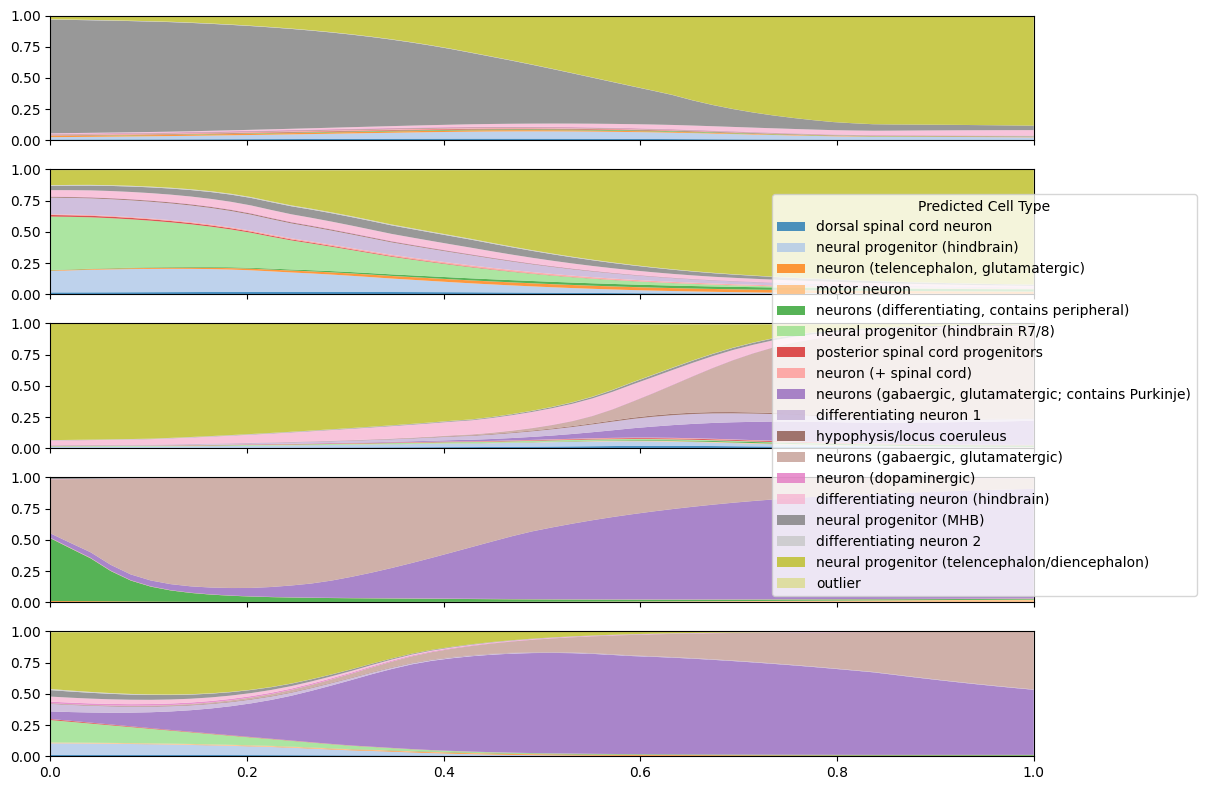

In [20]:
device = embed_model.device

batch = next(iter(paired_dataloader))
x0, x1, _, _ = embed_model._prepare_batch(batch)

paths = embed_model.sample_geodesic_path(batch, num_points=50)
paths_flat = paths.reshape(-1, paths.shape[-1])

time_axis = np.linspace(0, 1, 50)

with torch.no_grad():
    logits = classifier_model.classify(torch.tensor(paths_flat, device=device).float())
    probs = torch.softmax(logits, dim=1).cpu().numpy()
    
probs = probs.reshape(paths.shape[0], paths.shape[1], -1)

itos = adata.uns['itos']
cell_types = [itos[i] for i in range(len(itos))] + ["outlier"]

fig, axes = plt.subplots(5, figsize=(12, 8), sharex=True, sharey=True)

flat_axes = axes.flatten()

for i in range(len(flat_axes)):
    traj = probs[:,i]
    ax = flat_axes[i]
    ax.stackplot(time_axis, traj.T, labels=cell_types, alpha=0.8, colors=plt.cm.tab20.colors)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

handles, labels = flat_axes[0].get_legend_handles_labels()

fig.legend(
    handles, 
    labels, 
    loc='center right',       # Position on the right edge
    bbox_to_anchor=(1, 0.5),  # Anchor point relative to figure
    title="Predicted Cell Type"
)

plt.tight_layout(rect=[0, 0, 0.88, 1]) 
plt.show()

In [21]:
start = paths[0,:30]
end = paths[-1,:30]
itos = adata.uns['itos']
start_classes = torch.argmax(classifier_model.classify(start), dim=1).detach().cpu().numpy()
start_classes = [itos[i] for i in start_classes]
end_classes = torch.argmax(classifier_model.classify(end), dim=1).detach().cpu().numpy()
end_classes = [itos[i] for i in end_classes]

for i in range(30):
    print(f"{start_classes[i]:<50} {end_classes[i]:>50}")


neural progenitor (MHB)                                neural progenitor (telencephalon/diencephalon)
neural progenitor (hindbrain R7/8)                     neural progenitor (telencephalon/diencephalon)
neural progenitor (telencephalon/diencephalon)                     neurons (gabaergic, glutamatergic)
neurons (differentiating, contains peripheral)     neurons (gabaergic, glutamatergic; contains Purkinje)
neural progenitor (telencephalon/diencephalon)     neurons (gabaergic, glutamatergic; contains Purkinje)
neural progenitor (hindbrain R7/8)                              neuron (telencephalon, glutamatergic)
neural progenitor (telencephalon/diencephalon)                     neurons (gabaergic, glutamatergic)
neural progenitor (hindbrain)                          neural progenitor (telencephalon/diencephalon)
neural progenitor (hindbrain R7/8)                 neurons (gabaergic, glutamatergic; contains Purkinje)
neural progenitor (hindbrain)                      neurons (gabaergic, gl

In [22]:
#36->48->72
#geomloss
#TODO: reintroduce UOT with confirmation that it's working

#CFM: 15.929224967956543
#CFM + Finsler: 15.754395484924316

#MFM-Euc: 15.122610092163086
#MFM: 15.078815460205078
#MFM + Finsler: 15.24450969696045

In [23]:
#EMBED VALIDATION
if config.metric == "cfm" and not config.finsler.use:
    x0, x1, _, _= embed_model._prepare_batch(batch)
    x0, x1 = x0[0], x1[0]
    x0_, x1_, _, _ = embed_model.flow_matcher.ot_sampler.sample_plan(x0, x1)
    true_dist = torch.norm(x0 - x1, dim = -1)
    f = embed_model.embed_fn
    learned_dist = torch.norm(f(x0).detach() - f(x1).detach(), dim=-1)
    print(torch.stack([true_dist, learned_dist], dim=1)[:10])

tensor([[0.5198, 0.5345],
        [0.3948, 0.4138],
        [0.4908, 0.4899],
        [0.4301, 0.4304],
        [0.5294, 0.5418],
        [0.4829, 0.5058],
        [0.5194, 0.5318],
        [0.4457, 0.4593],
        [0.5073, 0.5199],
        [0.4611, 0.4713]])


In [24]:
#24->36,48->72
#POT

#CFM: 16.1572
#CFM + Finsler: 15.9079

#MFM-Euc: 
#MFM: 
#MFM + Finsler:

In [25]:
paths.shape

torch.Size([50, 512, 100])

In [26]:
import umap
import numpy as np
import matplotlib.pyplot as plt

X_data = adata.obsm['X_pca']

umap_model = umap.UMAP(n_neighbors=15, min_dist=0.5, metric='euclidean') 
X_umap = umap_model.fit_transform(X_data)
adata.obsm['X_umap'] = X_umap

traj_umap = umap_model.transform(paths.reshape(-1, 100))
traj_umap = traj_umap.reshape((-1, 512, 2))

/tmp/ipykernel_690898/4275250382.py:9: ImplicitModificationWarning: Setting element `.obsm['X_umap']` of view, initializing view as actual.
  adata.obsm['X_umap'] = X_umap


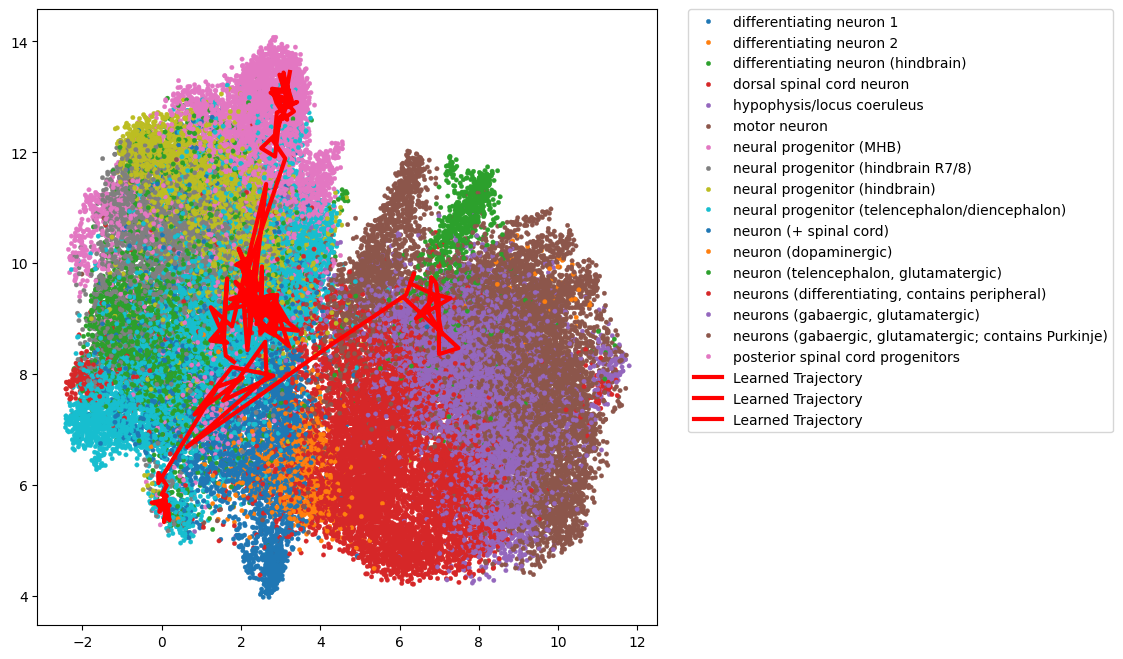

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

In [27]:

import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 8))

sns.scatterplot(
    x=X_umap[:, 0],
    y=X_umap[:, 1],
    hue=adata.obs['cell_type'], # Directly pass the categorical column
    s=10,
    ax=ax,
    palette='tab10', # Or use a specific palette
    edgecolor=None   # Removes outlines for a cleaner look
)
for i in range(3):
    plt.plot(traj_umap[:, i, 0], traj_umap[:,i, 1], c='red', linewidth=3, label='Learned Trajectory')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.show()

plt.figure(figsize=(8,8))

